---
title: "Lecture 5: Vector and matrix norms, Fixed-point and splitting methods"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture5_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: mathjax
    html: 
        output-file: Lecture5
        code-fold: true
        embed-resources: true
        code-links:
        - text: "Open in Colab"
          href: "https://colab.research.google.com/github/jamiehadd/Math-189M-NumericalLinearAlgebra/blob/main/Lecture5_Vector_and_matrix_norms_Fixedpoint_and_splitting_methods.ipynb"
          icon: "laptop"
    pdf:
        output-file: Lecture5
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
colab:
  gh-user: "jamiehadd"   
  gh-repo: "Math-189M-NumericalLinearAlgebra" 
filters: 
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

# Vector and Matrix Norms

Measuring magnitude and length is fundamental to vector and matrix analysis, and will be fundamental to our analysis of numerical methods.  Recall that a **norm** $\|\cdot\|$ is a real-valued function defined over a vector space with the following properties for all vectors and scalars $\alpha$:

* $\|\mathbf{x}\| \ge 0$
* $\|\mathbf{x}\| = 0 \iff \mathbf{x} = \mathbf{0}$
* $\|\alpha \mathbf{x}\| = |\alpha| \|\mathbf{x}\|$
* $\|\mathbf{x} + \mathbf{y}\| \le \|\mathbf{x}\| + \|\mathbf{y}\|$

## Vector Norms

Perhaps the most commonly encountered vector norms on $\mathbb{R}^n$ are these three:

* $\ell_2$ norm: $\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^n x_i^2}$
* $\ell_\infty$ norm: $\|\mathbf{x}\|_\infty = \max_{i=1, \cdots, n} |x_i|$
* $\ell_1$ norm: $\|\mathbf{x}\|_1 = \sum_{i=1}^n |x_i|$

In [1]:
using LinearAlgebra

x = [2, -3, 1, -1]
twonorm = norm(x)

3.872983346207417

In [2]:
infnorm = norm(x,Inf)

3.0

In [3]:
onenorm = norm(x,1)

7.0

---

We say that a sequence of vectors $\mathbf{x}_1, \mathbf{x}_2, \cdots$ **converges** to $\mathbf{x}$ if $$\lim_{k \rightarrow \infty} \|\mathbf{x}_k - \mathbf{x}\| = 0.$$

This will be very important as we begin to study iterative methods!

. . .

::: {.callout-warning icon=false}
## Theorem: Norm equivalence
In a finite-dimensional space, convergence in any norm implies convergence in all norms.
:::

## Matrix norms

As you may recall from Linear Algebra, the space of real-valued matrices of a given size define a vector space.  There are many norms for this vector space.  One such norm is quite interesting since it has a nice interpretation.  

. . .

This norm is the **Frobenius norm** and it is defined as $$\|\mathbf{A}\|_F = \sqrt{\sum_{i,j} A_{ij}^2}.$$

[This norm is what is by default computed by the `norm` function in Julia.]{.content-hidden when-format='revealjs' when-format='pptx'} 

[One of the most interesting aspects of this norm is that we can view it as the $\ell_2$ norm on a *vectorization* of the matrix.  If you imagine stacking columns of $\mathbf{A}$ to form a vector, then the $\ell_2$ norm of this vector is equal to the Frobenius norm of the matrix.]{.content-hidden when-format='revealjs' when-format='pptx'} 

[Matrices are actually column-stacked when stored in memory in Julia -- this is known as *column-major order*.  `MATLAB` is also column-major, while `C` and `Python` are row-major.]{.content-hidden when-format='revealjs' when-format='pptx'}

. . .

However, note that this norm does not inherently involve the *action* of the matrix as an *operator*.  There are other matrix norms which do, and these are sometimes more useful.

::: {.callout-note icon=false}
## Definition: Induced (natural) matrix norms
Given a vector norm $\|\cdot\|$, the **induced** or **natural matrix norm** for any $m \times n$ matrix $\mathbf{A}$ is $$\|\mathbf{A}\| = \max_{\|\mathbf{x}\| = 1} \|\mathbf{A}\mathbf{x}\| = \max_{\mathbf{x} \not= 0} \frac{\|\mathbf{A}\mathbf{x}\|}{\|\mathbf{x}\|}.$$
:::

---

The induced norm definition causes these norms to satisfy some useful inequalities:

::: {.callout-warning icon=false}
## Theorem: Norm inequalities
Let $\|\cdot\|$ designate a matrix norm and the vector norm that induced it.  Then for all matrices and vectors of compatible sizes, $$\|\mathbf{A}\mathbf{x}\| \le \|\mathbf{A}\| \|\mathbf{x}\|.$$
For all matrices of compatible sizes, $$\|\mathbf{A}\mathbf{B}\| \le \|\mathbf{A}\| \|\mathbf{B}\|.$$
:::

::: {.callout-caution icon=false}
## Exercise: Prove these inequalities!
Use the definition of an induced norm and the vector norm that induces it.
:::


<details><summary>Answer:</summary> 

For the first, if $\mathbf{x} = \mathbf{0}$, then $\|\mathbf{A}\mathbf{x}\| = 0 = \|\mathbf{A}\| \|\mathbf{x}\|$.  Now, we can deal only with the case $\mathbf{x} \not= 0$, $$\frac{\|\mathbf{A}\mathbf{x}\|}{\|\mathbf{x}\|} \le \max_{\mathbf{x} \not= \mathbf{0}} \frac{\|\mathbf{A}\mathbf{x}\|}{\|\mathbf{x}\|} = \|\mathbf{A}\|.$$
</details>

<details><summary>Answer:</summary> 

For the second, $$\|\mathbf{A}\mathbf{B}\| = \max_{\mathbf{x} \not= \mathbf{0}} \frac{\|\mathbf{AB}\mathbf{x}\|}{\|\mathbf{x}\|} \le \max_{\mathbf{x} \not= \mathbf{0}} \frac{\|\mathbf{A}\|\|\mathbf{B}\mathbf{x}\|}{\|\mathbf{x}\|}\le \max_{\mathbf{x} \not= \mathbf{0}} \frac{\|\mathbf{A}\|\|\mathbf{B}\|\|\mathbf{x}\|}{\|\mathbf{x}\|} = \|\mathbf{A}\|\|\mathbf{B}\|.$$
</details>

---

The induced matrix $\infty$- and $1$-norms can be equivalently defined in terms of the entries of the matrix.

::: {.callout-warning icon=false}
## Theorem: Matrix $\infty$- and $1$-norms
$\|\mathbf{A}\|_\infty = \max_{1 \le i \le n} \sum_{j=1}^n |A_{ij}|$

$\|\mathbf{A}\|_1 = \max_{1 \le j \le n} \sum_{i=1}^n |A_{ij}|$
:::

In [4]:
A = [2 0; 1 -1]

2×2 Matrix{Int64}:
 2   0
 1  -1

In [5]:
Fronorm = norm(A)

2.449489742783178

In [6]:
twonorm = opnorm(A)

2.2882456112707374

---

We can also see that the entry-wise definitions of the $\infty$- and $1$-norms are equivalent to their *induced norm* definition.

In [7]:
onenorm = opnorm(A,1)

3.0

In [8]:
maximum( sum(abs.(A),dims=1) )

3

In [9]:
infnorm = opnorm(A,Inf)

2.0

In [10]:
maximum( sum(abs.(A),dims=2) )

2

---

Now, we'll try to construct a geometric interpretation of the $\ell_2$ norm.

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->

In [11]:
# sample a lot of vectors on the unit circle in R^2
theta = 2pi*(0:1/600:1)
x = [ fun(t) for fun in [cos,sin], t in theta ]; #what a cool comprehension!

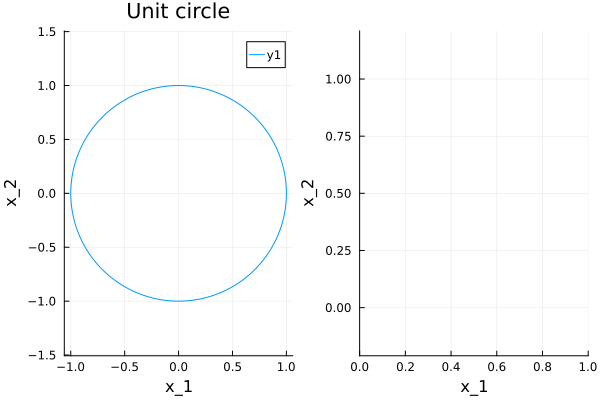

In [12]:
using Plots

plot(aspect_ratio=1, layout=(1,2), xlabel="x_1", ylabel="x_2") #creates a "layout" -- subsequent plot! calls actually add the individual subplots
plot!(x[1,:],x[2,:], subplot=1,title="Unit circle")

---

Now, the function $\mathbf{f}(\mathbf{x}) = \mathbf{A} \mathbf{x}$ defines a mapping from $\mathbb{R}^2$ to $\mathbb{R}^2$.  Let's see what this does to the vectors in the unit circle!

In [13]:
Ax = A*x;

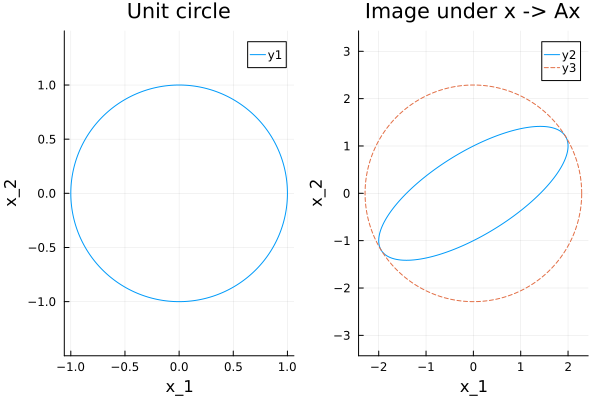

In [14]:
plot!(Ax[1,:],Ax[2,:],subplot=2,title="Image under x -> Ax")
plot!(twonorm*x[1,:],twonorm*x[2,:], subplot=2,l=:dash)

## Induced norms and eigenvalues

::: {.callout-note icon=false}
## Definition: Spectral radius
Given an $n\times n$ matrix $\mathbf{X}$, the **spectral radius** of matrix $\mathbf{X}$ is $$\rho(\mathbf{X}) := \max_{\lambda \text{ eigenvalue of }\mathbf{X}} |\lambda|.$$
:::

. . .

Induced matrix norms govern the eigenvalues of the matrix.

::: {.callout-warning icon=false}
## Theorem: Induced norms and spectral radius
Let $\mathbf{A}$ be an $n \times n$ matrix.  Then
1. $\|\mathbf{A}\|_2 = \sqrt{\rho(\mathbf{A}^\top\mathbf{A})}$
2. $\rho(\mathbf{A}) \le \|\mathbf{A}\|$ for any induced norm $\|\cdot\|$
:::

## Convergent matrices

::: {.callout-note icon=false}
## Definition: Convergent matrices
We call an $n \times n$ matrix $\mathbf{A}$ **convergent** if $$\lim_{k \rightarrow \infty} (\mathbf{A}^k)_{ij} = 0$$ for each $i = 1, \cdots, n$ and $j = 1, \cdots, n$.
:::

. . .

Induced norms and the spectral radius indicate which matrices are convergent.  These matrices will be useful to identify because they define convergent iterate methods, which we'll see next.

::: {.callout-warning icon=false}
## Theorem: Induced norms, spectral radius, and convergent matrices
The following are equivalent:

1. $\rho(\mathbf{A}) < 1$
2. $\lim_{n \rightarrow \infty} \|\mathbf{A}^n\| = 0$ for some induced norm
3. $\lim_{n \rightarrow \infty} \|\mathbf{A}^n\| = 0$ for all natural norms
4. $\mathbf{A}$ is a convergent matrix
5. $\lim_{n \rightarrow \infty} \mathbf{A}^n \mathbf{x} = \mathbf{0}$ for every $\mathbf{x} \in \mathbb{R}^n$
:::

# Iterative Methods for Solving Linear Systems

We've talked a bit last week about *direct* methods for solving linear systems of equations.  There is another class of methods known as *iterative methods* which use an iterative sequence of steps to make incremental improvement of an approximate solution to the system.  These methods typically use information from some subset of the system to make iterative improvements to the approximate solution (**iterate**).  

. . .

To introduce these methods, we introduce two archetypal problems forms tackled in numerical analysis.  The first is the **rootfinding problem**.  

. . .

*Many* problems in engineering, various sciences, data science, and machine learning can be rephrased as finding a root of a given function!  It is so important an archetypical problem that we study a variety of methods for this generic problem formulation, but you will see that many may be familiar from specific applications where they may go under different names.

## Rootfinding problem

::: {.callout-note icon=false}
## Definition: Rootfinding problem
Given a continuous function $\mathbf{f}$ of a variable input $\mathbf{v}$, the **rootfinding problem** is to find a real input $\mathbf{r}$, called a **root** such that $$\mathbf{f}(\mathbf{r}) = \mathbf{0}.$$
:::

. . .

In Calculus, you have likely already encountered such a problem.  In *optimization*, we often seek a *stationary point* of a given objective function as candidates for the maximizer or minimizer of a given function $L(\mathbf{x})$.  Mathematically, this is seeking $\mathbf{x}$ so that $$\nabla L(\mathbf{x}) = \mathbf{0}.$$

. . .

Most problems in linear algebra can be framed as a rootfinding problem.  The simplest example is a consistent linear system: $$\mathbf{A}\mathbf{x} = \mathbf{b} \iff \mathbf{f}(\mathbf{x}) = \mathbf{0} \text{ where } \mathbf{f}(\mathbf{x}) := \mathbf{A}\mathbf{x} - \mathbf{b}.$$

# Fixed-point iteration

We typically employ iterative methods to approximate a solution to a rootfinding problem.  The first method relies on a reformulation of the rootfinding problem as a **fixed-point problem**.

## Fixed-point problems

::: {.callout-note icon=false}
## Definition: Fixed-point problem
Given a function $\mathbf{g}$, the **fixed-point problem** is to find a value $\mathbf{p}$, called a **fixed point**, such that $\mathbf{g}(\mathbf{p}) = \mathbf{p}$.
:::

. . .

We may pass back and forth between equivalent fixed-point and rootfinding problems (meaning they have the same set of solutions).  

* Given a rootfinding problem defined by $\mathbf{f}$, we can define $\mathbf{g}(\mathbf{x}) = \mathbf{x} - \mathbf{f}(\mathbf{x})$.  Note that a root $\mathbf{r}$ satisfying $\mathbf{f}(\mathbf{r}) = \mathbf{0}$ is a fixed-point of $\mathbf{g}$: $$\mathbf{g}(\mathbf{r}) = \mathbf{r} - \mathbf{f}(\mathbf{r}) = \mathbf{r}.$$  (There are many other possible reductions.)
* Given a fixed-point problem defined by $\mathbf{g}$, we can define $\mathbf{f}(\mathbf{x}) = \mathbf{x} - \mathbf{g}(\mathbf{x})$.  Note that a fixed-point $\mathbf{p}$ satisfying $\mathbf{g}(\mathbf{p}) = \mathbf{p}$ is a root of $\mathbf{f}$: $$\mathbf{f}(\mathbf{p}) = \mathbf{p} - \mathbf{g}(\mathbf{p}) = \mathbf{p} - \mathbf{p} = \mathbf{0}.$$

## Algorithm

The reason that we are interested in transforming our problem to a fixed-point problem is that there is a very simple method for approximating a solution.  This method is known as the **fixed-point iteration** or **fixed-point iterative method**.

. . .

Given function $\mathbf{g}$ and initial value $\mathbf{x}_1$, define $$\mathbf{x}_{k+1} = \mathbf{g}(\mathbf{x}_k), \quad\quad\quad k = 1, 2, \cdots.$$

# Splitting Methods

A common class of fixed-point methods for solving linear systems are known as **splitting methods**.  These methods exploit a splitting of the matrix $\mathbf{A} = \mathbf{M} - \mathbf{N}$ to reformulate the linear system as an equivalent fixed-point problem:

. . .

$\mathbf{A}\mathbf{x} = \mathbf{b} \iff \mathbf{M}\mathbf{x} - \mathbf{N}\mathbf{x} = \mathbf{b} \iff \mathbf{x} = \mathbf{M}^{-1}\mathbf{N}\mathbf{x} + \mathbf{M}^{-1}\mathbf{b}$ so solution $\mathbf{x}$ is a fixed point of the function $\mathbf{f}(\mathbf{x}) := \mathbf{M}^{-1}\mathbf{N}\mathbf{x} + \mathbf{M}^{-1}\mathbf{b}$.

## Splitting method

::: {.callout-note icon=false}
## Definition: Splitting method update
Given a matrix $\mathbf{A} = \mathbf{M} - \mathbf{N},$ the update rule for a general splitting method is $$\mathbf{x}_{k+1} = \mathbf{M}^{-1}\mathbf{N}\mathbf{x}_k + \mathbf{M}^{-1}\mathbf{b}$$ given initial iterate $\mathbf{x}_0$.  (It is common to choose $\mathbf{x}_0 = \mathbf{0}$.)
:::

. . .

Let $\mathbf{e}^{(k)} := \mathbf{x}_k - \mathbf{x}$ be the error after the $k$th iteration, and note that
$$\begin{aligned}
\mathbf{e}^{(k+1)} &= \mathbf{x}_{k+1} - \mathbf{x} 
\\&= \mathbf{M}^{-1}\mathbf{N}\mathbf{x}_k + \mathbf{M}^{-1}\mathbf{b} - (\mathbf{M}^{-1}\mathbf{N}\mathbf{x} + \mathbf{M}^{-1}\mathbf{b})
\\&= \mathbf{M}^{-1}\mathbf{N}\mathbf{e}^{(k)}.
\end{aligned}$$

. . .

Thus, convergence depends only on the properties of matrix $\mathbf{M}^{-1}\mathbf{N}$!  We want this matrix to shrink vectors.

## Convergence of splitting methods

::: {.callout-warning icon=false}
## Theorem: Convergence of splitting methods
Given $\mathbf{b}$ and $\mathbf{A} = \mathbf{M} - \mathbf{N}$ with $\mathbf{A}$ and $\mathbf{M}$ nonsingular, the splitting method iterations converges, that is $\mathbf{x}_k \rightarrow \mathbf{x}$ for any starting vector $\mathbf{x}_0$ if and only if the spectral radius of $\mathbf{M}^{-1}\mathbf{N}$ satisfies $\rho(\mathbf{M}^{-1}\mathbf{N}) < 1$.
:::

<details><summary>Proof:</summary> 

($\Rightarrow$) In a homework exercise, you will prove this by contradiction.  You'll assume that $\rho(\mathbf{M}^{-1}\mathbf{N}) \ge 1$ and then choose an initial iterate $\mathbf{x}_0$ so that the $k$th error $\mathbf{e}^{(k)} = (\mathbf{M}^{-1}\mathbf{N})^k \mathbf{e}^{(0)}$ does not converge.  

($\Leftarrow$) Assume $\rho(\mathbf{M}^{-1}\mathbf{N}) < 1$.  We have then that $\mathbf{M}^{-1}\mathbf{N}$ is a convergent matrix, and thus,  $\lim_{n \rightarrow \infty} (\mathbf{M}^{-1}\mathbf{N})^n \mathbf{x} = \mathbf{0}$ for every $\mathbf{x} \in \mathbb{R}^n$.  Thus, $\mathbf{e}^{(k)} = (\mathbf{M}^{-1}\mathbf{N})^k \mathbf{e}^{(0)} \rightarrow \mathbf{0}$ for any initial vector $\mathbf{x}_0$.  
</details>


## How do we pick M and N?

We want this decomposition of $\mathbf{A} = \mathbf{M} - \mathbf{N}$ to satisfy two properties:

1. The chosen form of $\mathbf{M}$ should define linear systems $\mathbf{M}\mathbf{z} = \mathbf{d}$ that are easy to solve.  (E.g., diagonal or upper-triangular)
2. The chosen forms of $\mathbf{M}$ and $\mathbf{N}$ should satisfy $\rho(\mathbf{M}^{-1}\mathbf{N}) < 1$ for a reasonably broad class of matrices $\mathbf{A} = \mathbf{M} - \mathbf{N}$.

We'll see examples of choices of $\mathbf{M}$ and $\mathbf{N}$, and the splitting methods they define, in the next lecture!